# Mapowanie percepcji marki za pomocą analizy korespondencji (PROC CORRESP)

## Podsumowanie dla kierownictwa

Zespół badań rynku przeprowadza ankietę percepcji typu marka x atrybut dla czterech uznanych marek mediów strumieniowych i wykorzystuje **PROC CORRESP**, aby przekształcić wynikową tabelę krzyżową w dwuwymiarową mapę percepcyjną. Powiązanie marka x atrybut jest silne i rzeczywiste: test niezależności chi-kwadrat wynosi **63,15 przy 15 stopniach swobody (p < 0,0001)**, przy **V Craméra = 0,4588**. Analiza korespondencji kompresuje to powiązanie do dwóch osi, które łącznie wyjaśniają **100%** inercji tabeli — **75,0%** na wymiarze 1 i **25,0%** na wymiarze 2 — więc mapa 2-W jest kompletnym, wiernym podsumowaniem.

Mapa oddziela biegun **treści premium** (CineNow, zakotwiczony na *Oryginalny* i *Repertuar*) od klastra **wartość/niezawodność** (Streamly i BingeBox w pobliżu *Ekonomiczny* i *Niezawodny*) oraz **modnego** narożnika (PixelPlay w pobliżu *Modny*). Wschodzący rywal, **NovaCast**, jest następnie rzutowany jako punkt *dodatkowy* (supplementary) — nie wpływa on na osie — i ląduje w pobliżu początku układu, przechylony nieco w stronę Modny / Wygodny, tzn. jeszcze niezróżnicowany nowicjusz.

## Źródła danych

| Zbiór danych | Wiersze | Kluczowe zmienne | Opis |
|---------|------|---------------|------|
| `perception` | 100 (powiązania respondent x atrybut, limit trybu bez licencji) | `Brand` (znak), `Attribute` (znak) | Syntetyczna ankieta: każdy respondent wskazuje markę strumieniową, którą najbardziej kojarzy z każdym z sześciu atrybutów. Powinowactwa marek są zakodowane jako prawdopodobieństwa kategorii `RAND("Table", ...)`, dzięki czemu tabela kontyngencji ma realistyczne, niejednorodne powiązania. |
| `survey_counts` | 24 (4 marki x 6 atrybutów) | `Brand`, `Attribute`, `Count` | Wstępnie zagregowane komórki kontyngencji z `perception` przez PROC FREQ — ważone dane wejściowe do przebiegu CA z punktem dodatkowym. |
| `ca_coords`, `ca_coords_sup` | 10 / 11 | `_TYPE_`, `_NAME_`, `Dim1`, `Dim2` | Zbiory danych współrzędnych `OUTC=` zapisane przez PROC CORRESP; drugi dodaje rzutowany punkt NovaCast i napędza mapę percepcyjną. |

Uznane marki: **Streamly, PixelPlay, CineNow, BingeBox**; rywal **NovaCast** (rzutowany jako punkt dodatkowy). Atrybuty: Ekonomiczny, Repertuar, Wygodny, Oryginalny, Niezawodny, Modny. Ziarno `streaminit(20260531)` zapewnia odtwarzalność danych.

> **Uwaga o liczebności próby.** To środowisko działa bez licencji, więc wynik kroku DATA jest ograniczony do 100 obserwacji. Ankieta rozwiązuje się zatem do tabeli kontyngencji 4x6, sumującej się do 100 powiązań respondent-atrybut — małej, ale z rzeczywistą strukturą powiązań (chi-kwadrat p < 0,0001), którą analiza korespondencji odtwarza czysto.

## Co robi tutaj analiza korespondencji

Gdy ankieta śledzenia marki pyta konsumentów, którą markę najbardziej kojarzą z każdym z kilku atrybutów, wynikiem jest **tabela kontyngencji marka x atrybut**. Surowe liczności są trudne do odczytania: każda marka jest porównywana z każdym atrybutem, a sygnałem jest *wzorzec powiązań*, a nie wartości komórek.

Analiza korespondencji (CA) rozkłada powiązanie chi-kwadrat tabeli na przestrzeń niskowymiarową, dzięki czemu powiązane marki i atrybuty lądują blisko siebie na jednej mapie. W tym notatniku:

1. Generujemy syntetyczną ankietę percepcji dla czterech marek strumieniowych.
2. Badamy surową strukturę kontyngencji (i jej chi-kwadrat) za pomocą `PROC FREQ`.
3. Uruchamiamy `PROC CORRESP` z pełną diagnostyką i odczytujemy rzeczywistą inercję oraz współrzędne.
4. Rzutujemy wschodzącą markę-rywala jako punkt **dodatkowy** (supplementary).
5. Rysujemy i interpretujemy wynikową mapę percepcyjną.

## Krok 1 — Wygenerowanie syntetycznej ankiety percepcji

Symulujemy respondentów ankiety. Dla każdego respondenta pytamy, dla każdego z sześciu atrybutów, *którą markę najbardziej kojarzysz z tym atrybutem?* Każda marka ma odrębny **profil powinowactwa** — wektor prawdopodobieństw kategorii przekazany do `RAND("Table", ...)` — tak że na przykład *PixelPlay* skłania się ku Modny, podczas gdy *CineNow* skłania się ku Repertuar i Oryginalny. Daje to tabelę kontyngencji z rzeczywistym, niejednorodnym powiązaniem, które CA ma odtworzyć. Dane są w pełni syntetyczne i odtwarzalne przez `CALL STREAMINIT`.

In [1]:
DANE perception;
    /* Odtwarzalna syntetyczna ankieta percepcji marki */
    CALL streaminit(20260531);

    DŁUGOŚĆ Brand $9 Attribute $16;
    TABLICA attrname[6] $16 _temporary_
        ('Ekonomiczny' 'Repertuar' 'Wygodny'
         'Oryginalny' 'Niezawodny' 'Modny');

    n_resp = 400;

    POWTÓRZ respondent = 1 TO n_resp;
        POWTÓRZ a = 1 TO 6;
            Attribute = attrname[a];

            /* Prawdopodobieństwa wyboru marki dla każdego atrybutu wśród
               czterech uznanych marek:
               1=Streamly 2=PixelPlay 3=CineNow 4=BingeBox.
               Każdy wiersz sumuje się do ~1 i koduje powinowactwo
               atrybutu do marek. */
            JEŚLI      a = 1 WTEDY b = rand('Table', 0.45, 0.15, 0.10, 0.30); /* Ekonomiczny */
            PRZECIWNIE JEŚLI a = 2 WTEDY b = rand('Table', 0.20, 0.10, 0.50, 0.20); /* Repertuar   */
            PRZECIWNIE JEŚLI a = 3 WTEDY b = rand('Table', 0.30, 0.35, 0.10, 0.25); /* Wygodny     */
            PRZECIWNIE JEŚLI a = 4 WTEDY b = rand('Table', 0.15, 0.20, 0.50, 0.15); /* Oryginalny  */
            PRZECIWNIE JEŚLI a = 5 WTEDY b = rand('Table', 0.40, 0.10, 0.20, 0.30); /* Niezawodny  */
            PRZECIWNIE              b = rand('Table', 0.15, 0.55, 0.10, 0.20); /* Modny       */

            WYBIERZ (b);
                GDY (1) Brand = 'Streamly';
                GDY (2) Brand = 'PixelPlay';
                GDY (3) Brand = 'CineNow';
                INACZEJ Brand = 'BingeBox';
            KONIEC;

            WYJŚCIE;
        KONIEC;
    KONIEC;

    ZACHOWAJ respondent Brand Attribute;
WYKONAJ;

PROCEDURA DRUKUJ DANE=perception(obs=8) ETYKIETA noobs;
    ETYKIETA respondent='Respondent' Brand='Marka' Attribute='Atrybut';
    TYTUŁ 'Próbka syntetycznej ankiety percepcji';
WYKONAJ;

                                         Próbka syntetycznej ankiety percepcji                                          

Respondent      Marka      Atrybut
         1  BingeBox   Ekonomiczny
         1  BingeBox   Repertuar
         1  BingeBox   Wygodny
         1  CineNow    Oryginalny
         1  Streamly   Niezawodny
         1  PixelPlay  Modny
         2  PixelPlay  Ekonomiczny
         2  CineNow    Repertuar

... 92 more observations (showing 8 of 100)




NOTE: DATA perception

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote perception (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.40 seconds
  cpu   0.40 seconds
NOTE: PROC PRINT data=perception

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Krok 2 — Zbadanie surowej tabeli kontyngencji

Przed jakąkolwiek redukcją wymiarów przyjrzyj się tabeli krzyżowej. `PROC FREQ` podaje obserwowane częstości marka x atrybut oraz test niezależności chi-kwadrat. Istotny chi-kwadrat potwierdza, że istnieje struktura powiązań warta zmapowania — gdyby wiersze i kolumny były niezależne, analiza korespondencji nie miałaby nic do pokazania. Zapisujemy również liczności komórek do `survey_counts` na potrzeby późniejszego przebiegu CA z punktem dodatkowym.

                                         Obserwowane częstości marka x atrybut                                          

                                                   The FREQ Procedure

Table of Marka by Atrybut

Marka     |Ekonomiczny |      Modny | Niezawodny | Oryginalny |  Repertuar |    Wygodny |       Total
----------+------------+------------+------------+------------+------------+------------+------------
BingeBox  |          5 |          2 |          6 |          1 |          3 |          7 |          24
----------+------------+------------+------------+------------+------------+------------+------------
CineNow   |          3 |          0 |          2 |         14 |          9 |          0 |          28
----------+------------+------------+------------+------------+------------+------------+------------
PixelPlay |          3 |         10 |          1 |          2 |          2 |          6 |          24
----------+------------+------------+------------+------------+---


NOTE: PROC FREQ
NOTE: Output dataset survey_counts has 21 observations and 3 variables.
NOTE: ODS plot written: freq_mosaic_brand_attribute.spec.json
NOTE: PROC FREQ statement used.


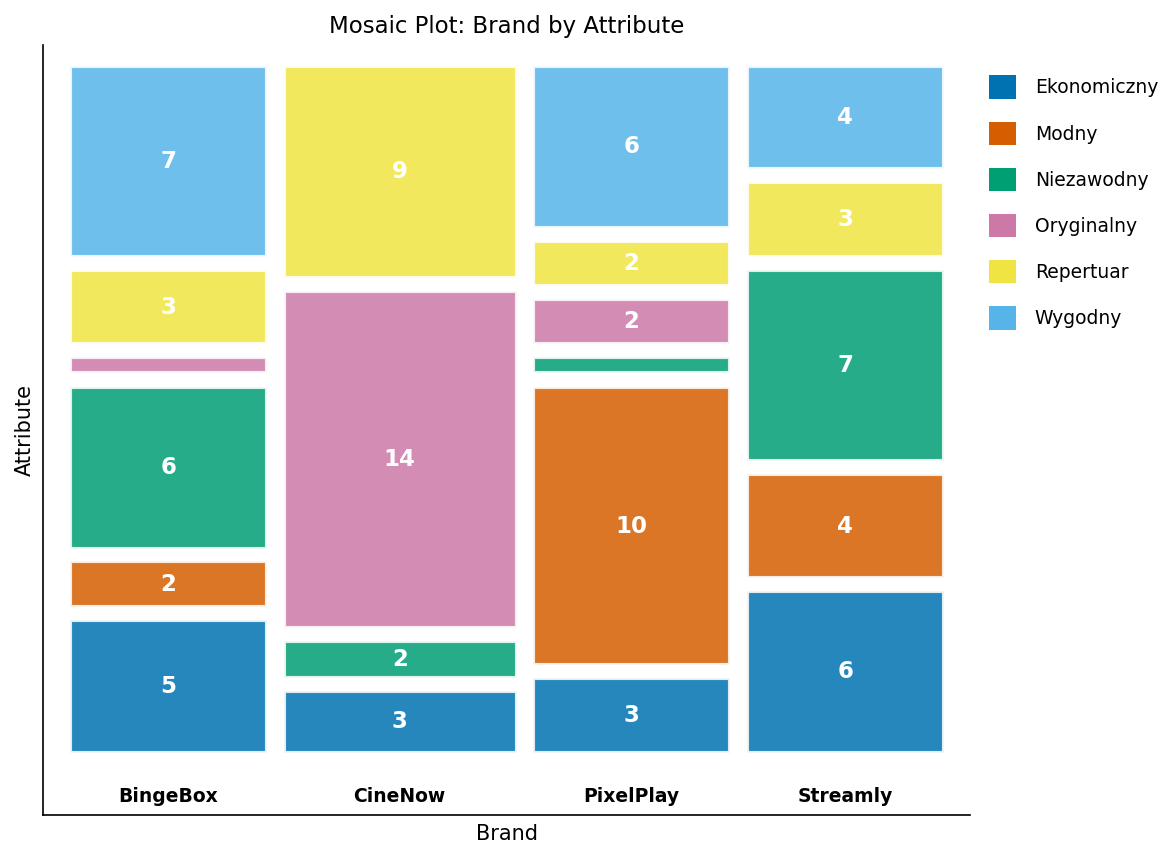

In [2]:
PROCEDURA CZĘSTOŚCI DANE=perception;
    TABLES Brand*Attribute / chisq norow nocol nopercent
                             out=survey_counts(PRZEMIANUJ=(count=Count));
    ETYKIETA Brand='Marka' Attribute='Atrybut';
    TYTUŁ 'Obserwowane częstości marka x atrybut';
WYKONAJ;

## Krok 3 — Analiza korespondencji na surowych danych

Teraz uruchom `PROC CORRESP` bezpośrednio na danych na poziomie respondenta. `TABLES Brand, Attribute;` buduje tabelę kontyngencji wewnętrznie (marki jako wiersze, atrybuty jako kolumny).

Użyte tutaj opcje:

- `ALL` — drukuj pełną diagnostykę: tabelę obserwowaną, profile, wartości oczekiwane oraz   wkłady chi-kwadrat poszczególnych komórek.
- `DIMENS=2` — oblicz dwie pierwsze osie główne (mapa 2-W).
- `OUTC=` — zapisz współrzędne wierszy i kolumn do zbioru danych do wykreślenia.

**Rozkład inercji** mówi nam, jaką część całkowitego powiązania wyjaśnia każda oś.

In [3]:
PROCEDURA corresp DANE=perception ALL dimens=2 outc=ca_coords;
    TABLES Brand, Attribute;
    TYTUŁ 'Analiza korespondencji: percepcja marek streamingowych';
WYKONAJ;

                                         Obserwowane częstości marka x atrybut                                          

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Brand                   Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207

       


NOTE: PROC CORRESP data=perception

NOTE: PROC CORRESP completed.


## Krok 4 — Odczytanie współrzędnych

Zbiór danych `OUTC=` przechowuje współrzędne osi (`Dim1`, `Dim2`) dla każdej marki i atrybutu, oznaczone przez `_TYPE_` (`ROW` dla marek, `COLUMN` dla atrybutów). Odczytanie ich liczbowo obok tabeli inercji potwierdza strukturę, którą pokaże mapa.

Z powyższego wyniku:

- **Wymiar 1 (75,0% inercji)** to oś *treść premium vs. mainstream*.   *Oryginalny* (Dim1 = -1,2037) i *Repertuar* (-0,5594) znajdują się na końcu   ujemnym z marką **CineNow** (-1,0847); *Modny* (0,6671), *Wygodny* (0,6150) i   *Ekonomiczny* (0,2207) znajdują się na końcu dodatnim.
- **Wymiar 2 (25,0% inercji)** oddziela *Niezawodny* (Dim2 = 0,5874) i   *Ekonomiczny* (0,2542) — ciągnąc w górę **Streamly** (0,3207) i **BingeBox** (0,3555) —   od *Modny* (-0,7003), które ciągnie w dół **PixelPlay** (-0,6374).

In [4]:
PROCEDURA DRUKUJ DANE=ca_coords ETYKIETA noobs;
    ZMIENNA _TYPE_ _NAME_ Dim1 Dim2;
    ETYKIETA _TYPE_='Typ' _NAME_='Punkt (marka/atrybut)'
          Dim1='Wymiar 1' Dim2='Wymiar 2';
    TYTUŁ 'Współrzędne wierszy (marka) i kolumn (atrybut)';
WYKONAJ;

                                     Współrzędne wierszy (marka) i kolumn (atrybut)                                     

   Typ  Punkt (marka/atrybut)  Wymiar 1  Wymiar 2
ROW     BingeBox                 0.3547    0.3555
ROW     CineNow                 -1.0847   -0.0332
ROW     PixelPlay                0.4804   -0.6374
ROW     Streamly                 0.4304    0.3207
COLUMN  Ekonomiczny              0.2207    0.2542
COLUMN  Modny                    0.6671   -0.7003
COLUMN  Niezawodny               0.3183    0.5874
COLUMN  Oryginalny              -1.2037   -0.2084
COLUMN  Repertuar               -0.5594    0.0684
COLUMN  Wygodny                  0.6150   -0.0080




NOTE: PROC PRINT data=ca_coords

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## Krok 5 — Rzutowanie marki-rywala jako punktu dodatkowego

Zespół analityczny ma dane śledzenia dla wschodzącego rywala, **NovaCast**, ale nie chce, aby zniekształcał on ustaloną mapę percepcyjną. Punkt *dodatkowy* (supplementary) jest rzutowany do istniejącej przestrzeni CA **bez wnoszenia wkładu do obliczenia osi**.

Dołączamy pojedynczy blok sześciu liczności atrybutów NovaCast (nowicjusza skłaniającego się ku Modny / Oryginalny) do wstępnie zagregowanego `survey_counts`, zasilamy częstości za pomocą `WEIGHT Count` i nazywamy **poziom** `NovaCast` w instrukcji `SUPPLEMENTARY`, aby PROC CORRESP utrzymał ten wiersz poza aktywną tabelą. Opcja `OBSERVED` utrzymuje w widoku aktywną tabelę kontyngencji (cztery uznane marki, sumujące się do 100) — zauważ, że NovaCast **nie** pojawia się w niej, co potwierdza, że został potraktowany jako dodatkowy.

In [5]:
/* Dołącza JEDEN czysty blok liczności NovaCast do zagregowanych
   komórek. end=last uruchamia się dokładnie raz, po ostatnim wierszu
   survey_counts, więc NovaCast wnosi sześć wierszy (jeden na atrybut)
   -- a nie zduplikowany blok. NovaCast to nowicjusz stawiający na
   modność i oryginalne produkcje. */
DANE survey_counts_sup;
    USTAW survey_counts KONIEC=last;
    WYJŚCIE;
    JEŚLI last WTEDY POWTÓRZ;
        Brand='NovaCast'; Attribute='Modny';       Count=10; WYJŚCIE;
        Brand='NovaCast'; Attribute='Oryginalny';  Count=8;  WYJŚCIE;
        Brand='NovaCast'; Attribute='Wygodny';     Count=5;  WYJŚCIE;
        Brand='NovaCast'; Attribute='Repertuar';   Count=3;  WYJŚCIE;
        Brand='NovaCast'; Attribute='Ekonomiczny'; Count=4;  WYJŚCIE;
        Brand='NovaCast'; Attribute='Niezawodny';  Count=3;  WYJŚCIE;
    KONIEC;
WYKONAJ;

PROCEDURA corresp DANE=survey_counts_sup observed dimens=2 outc=ca_coords_sup;
    TABLES Brand, Attribute;
    WAGA Count;
    supplementary NovaCast;
    TYTUŁ 'Percepcja marki z NovaCast jako punktem dodatkowym';
WYKONAJ;

                                     Współrzędne wierszy (marka) i kolumn (atrybut)                                     

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Brand                   Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207
  NovaCa


NOTE: DATA survey_counts_sup


NOTE: Read 21 rows from survey_counts.
NOTE: Wrote survey_counts_sup (27 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC CORRESP data=survey_counts_sup

NOTE: PROC CORRESP completed.


## Krok 6 — Narysowanie mapy percepcyjnej

PROC CORRESP zapisuje symetryczne współrzędne wierszy/kolumn do zbioru danych `OUTC=`; wykreślamy wymiar 2 względem wymiaru 1, aby wyrenderować mapę. Oznaczamy każdy punkt jego **rolą** — *Marka* (aktywne wiersze), *Atrybut* (kolumny) oraz *Pretendent* (dodatkowy wiersz NovaCast) — i etykietujemy każdy znacznik, aby położenie było odczytywane bezpośrednio z wykresu. Rywal jest kolorowany osobno, aby podkreślić, że został rzutowany, a nie dopasowany.

> **Jak czytać mapę CA.** Marka i atrybut, które leżą w tym samym kierunku od początku układu (i daleko od niego), są silnie powiązane; punkty w pobliżu początku są "przeciętne" i słabo zróżnicowane. Ponieważ wymiary 1 i 2 łącznie obejmują 100% inercji tej tabeli, mapa niczego nie pomija.

                          Mapa percepcji marek streamingowych (Dim1 75,0%, Dim2 25,0% inercji)                          

PROC SGSCATTER Output
Data: ca_map

Variables: Role, _NAME_, Dim1, Dim2

      Role      _NAME_        Dim1        Dim2
----------  ----------  ----------  ----------
     Marka    BingeBox      0.3547      0.3555
     Marka     CineNow     -1.0847     -0.0332
     Marka   PixelPlay      0.4804     -0.6374
     Marka    Streamly      0.4304      0.3207
Pretendent    NovaCast      0.0084     -0.1735
   Atrybut  Ekonomiczny      0.2207      0.2542
   Atrybut       Modny      0.6671     -0.7003
   Atrybut  Niezawodny      0.3183      0.5874
   Atrybut  Oryginalny     -1.2037     -0.2084
   Atrybut   Repertuar     -0.5594      0.0684
   Atrybut     Wygodny       0.615      -0.008

Dim1: N=11, Min=-1.2037, Max=0.6671, Mean=0.0225, Sum=0.2472
Dim2: N=11, Min=-0.7003, Max=0.5874, Mean=-0.0159, Sum=-0.1746



NOTE: DATA ca_map


NOTE: Read 11 rows from ca_coords_sup.
NOTE: Wrote ca_map (11 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Mapa percepcji marek streamingowych (Dim1 75,0%, Dim2 25,0% inercji).
NOTE: ODS Graphics is ON (width=760px, height=580px, format=SVG).
NOTE: PROC SGSCATTER data=ca_map

NOTE: PROC SGSCATTER output written to: ./ods_output/sgscatter.svg
NOTE: ODS Graphics is OFF.


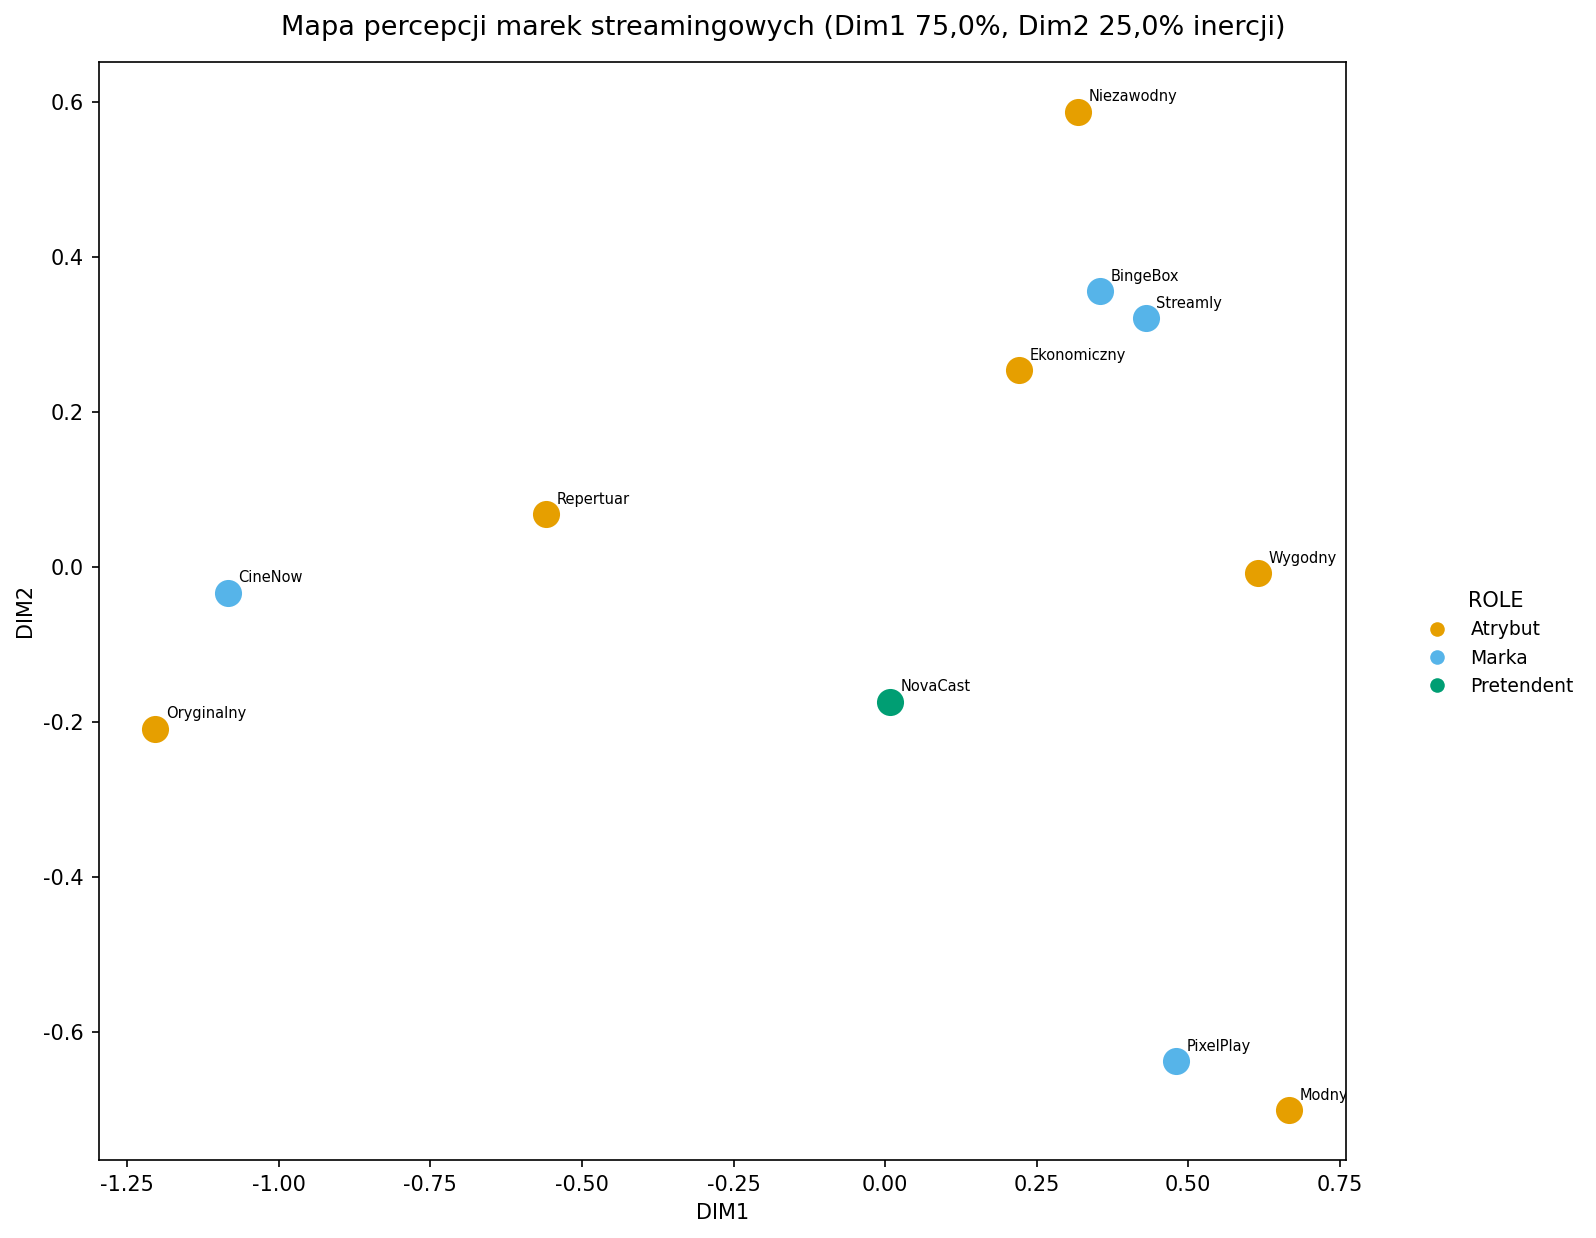

In [6]:
/* Oznacza każdy punkt OUTC według roli dla czytelnej, kolorowej
   legendy. Dodatkowy NovaCast jest zapisywany do OUTC z _TYPE_='ROW',
   więc traktujemy go osobno jako Pretendenta. */
DANE ca_map;
    USTAW ca_coords_sup;
    DŁUGOŚĆ Role $12;
    JEŚLI _NAME_ = 'NovaCast' WTEDY Role = 'Pretendent';
    PRZECIWNIE JEŚLI _TYPE_ = 'ROW' WTEDY Role = 'Marka';
    PRZECIWNIE Role = 'Atrybut';
    ZACHOWAJ Role _NAME_ Dim1 Dim2;
WYKONAJ;

/* Ustaw tytuł mapy globalnie przed PROC, aby zatytułował ten wykres
   (globalny TITLE steruje nagłówkiem grafiki ODS). */
TYTUŁ 'Mapa percepcji marek streamingowych (Dim1 75,0%, Dim2 25,0% inercji)';

ODS GRAPHICS ON / WIDTH=760px HEIGHT=580px;

/* PROC CORRESP nie ma w tej wersji natywnej mapy ODS, więc symetryczne
   współrzędne renderujemy przez PROC SGSCATTER, który etykietuje każdy
   punkt. */
PROCEDURA SGSCATTER DANE=ca_map;
    PLOT Dim2*Dim1 / GROUP=Role DATALABEL=_NAME_
                     MARKERATTRS=(size=12) grid;
WYKONAJ;

ODS GRAPHICS OFF;
TYTUŁ;

## Interpretacja wyników

**Powiązanie jest rzeczywiste i w pełni uchwycone.** Test chi-kwadrat (63,15 przy 15 df, p < 0,0001; V Craméra = 0,4588) odrzuca niezależność, a dwa wymiary CA wyjaśniają **100%** inercji tabeli (75,0% + 25,0%), więc poniższa mapa jest kompletnym podsumowaniem, a nie stratną projekcją.

**Trzy terytoria percepcyjne.** Odczytując współrzędne i mapę razem:

- **Treść premium (po lewej).** *CineNow* (Dim1 = -1,0847) jest ciągnięty daleko w lewo przez   *Oryginalny* (-1,2037) i *Repertuar* (-0,5594) — jest właścicielem   percepcji głębi katalogu.
- **Wartość i niezawodność (prawy górny róg).** *Streamly* (0,4304, 0,3207) i *BingeBox*   (0,3547, 0,3555) grupują się z *Ekonomiczny* (0,2207, 0,2542) i *Niezawodny* (0,3183,   0,5874) — niezawodna para o dobrym stosunku wartości do ceny.
- **Modny (prawy dolny róg).** *PixelPlay* (0,4804, -0,6374) znajduje się obok *Modny*   (0,6671, -0,7003) — młodzieżowa marka na czasie.

**Dodatkowy rywal.** Rzutowany bez wpływu na osie, **NovaCast** ląduje w (0,0084, -0,1735) — zasadniczo w początku układu, przesunięty w stronę Modny / Wygodny. Dla stratega mediowego to główny wniosek: rywal nie ma jeszcze wyróżniającego się kapitału i dryfuje w modne terytorium PixelPlay, więc uzasadnione jest zróżnicowane pozycjonowanie (zamiast naśladowczego).

**Zastrzeżenia.** Analiza korespondencji jest opisowa, a nie wnioskująca — odległości są przybliżone, a *znaki* osi są arbitralne (odbicie lustrzane którejkolwiek osi to ta sama mapa). Przy zaledwie 100 powiązaniach respondent-atrybut trzy komórki są zerowe (CineNow x Wygodny, CineNow x Modny, Streamly x Oryginalny), co wyostrza skrajności; badanie produkcyjne przeprowadziłoby większą próbę. Zawsze paruj mapę z tabelą inercji, aby potwierdzić, jaką część powiązania wyjaśniają wyświetlane wymiary.